In [56]:
# --- IMPORTAR LIBRERÍAS ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Carga de Datos y Análisis Exploratorio Inicial

In [5]:
df = pd.read_csv(r"C:\Users\anfre\Downloads\cardekho.csv")


In [6]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0


In [52]:
cars = df
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                8128 non-null   int64  
 1   selling_price       8128 non-null   int64  
 2   km_driven           8128 non-null   int64  
 3   fuel                8128 non-null   str    
 4   seller_type         8128 non-null   str    
 5   transmission        8128 non-null   str    
 6   owner               8128 non-null   str    
 7   mileage(km/ltr/kg)  8128 non-null   float64
 8   engine              8128 non-null   float64
 9   max_power           8128 non-null   float64
 10  seats               8128 non-null   float64
 11  owner_encoded       8128 non-null   float64
dtypes: float64(5), int64(3), str(4)
memory usage: 762.1 KB


In [47]:
cars['max_power'] = cars['max_power'].str.strip()

In [51]:
cars['max_power'] = cars['max_power'].astype(str).str.replace(r'[^0-9.\-]', '', regex=True)
cars['max_power'] = pd.to_numeric(cars['max_power'], errors='coerce')
cars['max_power'] = cars['max_power'].fillna(cars['max_power'].median())

In [53]:
cars.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,owner_encoded
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.000000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,91.264982,5.416719,1.459154
std,4.044249,8.062534e+05,5.655055e+04,3.981875,497.017504,35.376388,0.946450,0.717381
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000,0.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.000000,68.100000,5.000000,1.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.418783,1248.000000,82.000000,5.000000,1.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.277500,1582.000000,101.250000,5.000000,2.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000,4.000000


In [90]:
cars ["selling_price"].min()

np.int64(29999)

In [91]:
cars ["selling_price"].max()

np.int64(10000000)

In [92]:
cars ["selling_price"].mean()

np.float64(638271.8077017716)

## 2. Preprocesamiento de Datos e Ingeniería de Características


In [ ]:
cars.drop(columns='name', inplace=True)

In [37]:
cars['mileage(km/ltr/kg)'] = cars['mileage(km/ltr/kg)'].fillna(cars['mileage(km/ltr/kg)'].mean())

In [38]:
cars['engine'] = cars['engine'].fillna(cars['engine'].mean())

In [40]:
cars['seats'] = cars['seats'].fillna(cars['seats'].mean())

In [41]:
cars

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats,owner_encoded
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0,1.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,2.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0,3.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0,1.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.50,1197.0,82.85,5.0,1.0
8124,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.80,1493.0,110,5.0,4.0
8125,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.30,1248.0,73.9,5.0,1.0
8126,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57,1396.0,70,5.0,1.0


In [19]:
cars['fuel'].value_counts()

fuel
Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: count, dtype: int64

In [23]:
cars['seller_type'].value_counts()

seller_type
Individual          6766
Dealer              1126
Trustmark Dealer     236
Name: count, dtype: int64

In [20]:
cars['transmission'].value_counts()

transmission
Manual       7078
Automatic    1050
Name: count, dtype: int64

In [24]:
cars['owner'].value_counts()

owner
First Owner             5289
Second Owner            2105
Third Owner              555
Fourth & Above Owner     174
Test Drive Car             5
Name: count, dtype: int64

In [68]:
one_hot_encoded = pd.get_dummies(cars['fuel'])

print(one_hot_encoded)



        CNG  Diesel    LPG  Petrol
0     False    True  False   False
1     False    True  False   False
2     False   False  False    True
3     False    True  False   False
4     False   False  False    True
...     ...     ...    ...     ...
8123  False   False  False    True
8124  False    True  False   False
8125  False    True  False   False
8126  False    True  False   False
8127  False    True  False   False

[8128 rows x 4 columns]


In [25]:
one_hot_encoded1 = pd.get_dummies(cars['seller_type'])

print(one_hot_encoded1)

      Dealer  Individual  Trustmark Dealer
0      False        True             False
1      False        True             False
2      False        True             False
3      False        True             False
4      False        True             False
...      ...         ...               ...
8123   False        True             False
8124   False        True             False
8125   False        True             False
8126   False        True             False
8127   False        True             False

[8128 rows x 3 columns]


In [26]:
one_hot_encoded2 = pd.get_dummies(cars['transmission'])

print(one_hot_encoded2)

      Automatic  Manual
0         False    True
1         False    True
2         False    True
3         False    True
4         False    True
...         ...     ...
8123      False    True
8124      False    True
8125      False    True
8126      False    True
8127      False    True

[8128 rows x 2 columns]


In [59]:
from sklearn.preprocessing import OrdinalEncoder



# 2. Limpiar espacios en blanco al inicio o al final (opcional pero recomendado)
cars['owner'] = cars['owner'].str.strip()
orden_categorias = ['Test Drive Car', 'First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']

encoder = OrdinalEncoder(categories=[orden_categorias])
cars['owner_encoded'] = encoder.fit_transform(cars[['owner']])

print(f"Encoded Ordinal Data: {encoded_data}")

Encoded Ordinal Data: [[0.]
 [1.]
 [2.]
 ...
 [0.]
 [0.]
 [0.]]


In [73]:
cars

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,max_power,seats,owner_encoded,CNG_x,Diesel_x,...,Petrol_x,CNG_y,Diesel_y,LPG_y,Petrol_y,Dealer,Individual,Trustmark Dealer,Automatic,Manual
0,2014,450000,145500,23.40,1248.0,74.00,5.0,1.0,False,True,...,False,False,True,False,False,False,True,False,False,True
1,2014,370000,120000,21.14,1498.0,103.52,5.0,2.0,False,True,...,False,False,True,False,False,False,True,False,False,True
2,2006,158000,140000,17.70,1497.0,78.00,5.0,3.0,False,False,...,True,False,False,False,True,False,True,False,False,True
3,2010,225000,127000,23.00,1396.0,90.00,5.0,1.0,False,True,...,False,False,True,False,False,False,True,False,False,True
4,2007,130000,120000,16.10,1298.0,88.20,5.0,1.0,False,False,...,True,False,False,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,18.50,1197.0,82.85,5.0,1.0,False,False,...,True,False,False,False,True,False,True,False,False,True
8124,2007,135000,119000,16.80,1493.0,110.00,5.0,4.0,False,True,...,False,False,True,False,False,False,True,False,False,True
8125,2009,382000,120000,19.30,1248.0,73.90,5.0,1.0,False,True,...,False,False,True,False,False,False,True,False,False,True
8126,2013,290000,25000,23.57,1396.0,70.00,5.0,1.0,False,True,...,False,False,True,False,False,False,True,False,False,True


In [69]:
cars.drop(columns=['fuel', 'seller_type', 'transmission', 'owner'], inplace=True)

In [72]:
cars = cars.merge(one_hot_encoded, left_index=True, right_index=True)
cars = cars.merge(one_hot_encoded1, left_index=True, right_index=True)
cars = cars.merge(one_hot_encoded2, left_index=True, right_index=True)

In [75]:
# Definir variables independientes y dependiente
X = cars.drop(['selling_price'], axis=1)
y = cars['selling_price']

# Inicializar y aplicar el escalador
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [83]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [84]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

X_train shape: (6502, 20), X_test shape: (1626, 20)


In [85]:
X_train

array([[ 1.2848638 , -1.18944277,  1.15058821, ..., -0.17292686,
         2.59633441, -2.59633441],
       [-0.19881574,  0.18003564, -0.0047175 , ..., -0.17292686,
        -0.3851584 ,  0.3851584 ],
       [-0.69337558,  1.41794227,  0.89943479, ..., -0.17292686,
        -0.3851584 ,  0.3851584 ],
       ...,
       [ 0.54302403, -0.61576147, -0.20564024, ..., -0.17292686,
        -0.3851584 ,  0.3851584 ],
       [ 1.2848638 , -0.75723651,  2.25566323, ..., -0.17292686,
        -0.3851584 ,  0.3851584 ],
       [-1.9297752 ,  0.00319184, -0.83352377, ..., -0.17292686,
        -0.3851584 ,  0.3851584 ]], shape=(6502, 20))

In [86]:
from sklearn.ensemble import RandomForestRegressor
reg = LinearRegression().fit(X_train, y_train)

randomForest = RandomForestRegressor(n_estimators=100, random_state=42)
randomForest.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [87]:
y_pred_LR = reg.predict(pd.DataFrame(X_test))
y_pred_RF = randomForest.predict(pd.DataFrame(X_test))

In [88]:
print(f"Error cuadrático medio (LR): {mean_squared_error(y_test, y_pred_LR) ** 0.5}")
print(f"Error Absoluto Medio (LR): {mean_absolute_error(y_test, y_pred_LR):.3f}")
print(f"R2 Score (LR): {r2_score(y_test, y_pred_LR):.3f}")
print()
print(f"Error cuadrático medio (RF): {mean_squared_error(y_test, y_pred_RF) ** 0.5}")
print(f"Error Absoluto Medio (RF): {mean_absolute_error(y_test, y_pred_RF):.3f}")
print(f"R2 Score (RF): {r2_score(y_test, y_pred_RF):.3f}")


Error cuadrático medio (LR): 451809.26060067525
Error Absoluto Medio (LR): 270068.680
R2 Score (LR): 0.689

Error cuadrático medio (RF): 143292.3124519455
Error Absoluto Medio (RF): 69995.848
R2 Score (RF): 0.969


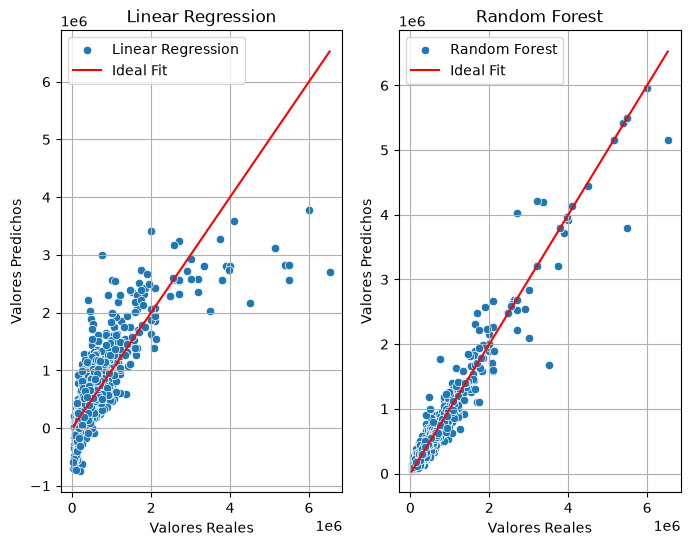

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

figure, ax = plt.subplots(1,2, figsize=(8, 6))

ax[0] =sns.scatterplot(x=y_test, y=y_pred_LR, label='Linear Regression', ax=ax[0])
ax[0] =sns.lineplot(x=y_test, y=y_test, color='red', label='Ideal Fit', ax=ax[0])
ax[0].set_xlabel('Valores Reales')
ax[0].set_ylabel('Valores Predichos')
ax[0].set_title('Linear Regression')
ax[0].grid()


ax[1] =sns.scatterplot(x=y_test, y=y_pred_RF, label='Random Forest', ax=ax[1])
ax[1] =sns.lineplot(x=y_test, y=y_test, color='red', label='Ideal Fit', ax=ax[1])
ax[1].set_xlabel('Valores Reales')
ax[1].set_ylabel('Valores Predichos')
ax[1].set_title('Random Forest')
ax[1].grid() 

El modelo de predicción de Regresión lineal tiene un margen de error de 451809.26 sobre el precio de los autos y este modelo explica un 68.9% de la varianza original de los datos reales

El modelo de predicción de RandomForest tiene un margen de error de 143292.31 sobre el precio de los autos y este modelo explica un 96.9% de la varianza original de los datos reales

En la grafica se logra observar que en el modelo de Randomforest los datos no estan tan dispersos sino que se ubican mas cerca de la linea